### GLM Binomial: Generalized Linear Model

Goal:
Predict the probability that any given hour will be a high-demand "peak" (is_peak) event (a binary Yes/No classification task).

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                              classification_report, accuracy_score)

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
os.makedirs('../outputs/figures/04_binomial', exist_ok=True)

df = pd.read_csv('../data/processed/hourly_merged.csv', index_col='datetime_utc')
df.index = pd.to_datetime(df.index, utc=True)

print(f'Shape: {df.shape}')
print(f'is_peak balance: {df["is_peak"].mean()*100:.1f}% peak hours')

Shape: (35045, 19)
is_peak balance: 10.0% peak hours


#### 1. Train / Test Split

In [22]:
train = df[df.index.year < 2025].copy()
test  = df[df.index.year == 2025].copy()

print(f'Train: {len(train):,} rows  |  {train["is_peak"].sum():,} peak hours ({train["is_peak"].mean()*100:.1f}%)')
print(f'Test:  {len(test):,} rows   |  {test["is_peak"].sum():,} peak hours ({test["is_peak"].mean()*100:.1f}%)')

Train: 26,286 rows  |  2,714 peak hours (10.3%)
Test:  8,759 rows   |  791 peak hours (9.0%)


#### 2. GLM Binomial

Logit link (default). Same predictors as the LM, with T:hour_cos interaction.

In [23]:
formula = (
    'is_peak ~ '
    'T + Hr + StrGlo + RainDur + WVv + p + '
    'hour_sin + hour_cos + month_sin + month_cos + '
    'is_weekend + C(season) + '
    'T:hour_cos'
)

pred_cols = ['T', 'Hr', 'StrGlo', 'RainDur', 'WVv', 'p']
train_clean = train.dropna(subset=pred_cols)
test_clean  = test.dropna(subset=pred_cols)

model = smf.glm(formula, data=train_clean, family=sm.families.Binomial()).fit()

pseudo_r2 = 1 - model.deviance / model.null_deviance
print(f'McFadden pseudo-R2 = {pseudo_r2:.4f}')
print(f'AIC = {model.aic:.1f}')
print(model.summary())

McFadden pseudo-R2 = 0.5254
AIC = 8308.6
                 Generalized Linear Model Regression Results                  
Dep. Variable:                is_peak   No. Observations:                26260
Model:                            GLM   Df Residuals:                    26244
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4138.3
Date:                Mon, 04 May 2026   Deviance:                       8276.6
Time:                        21:41:08   Pearson chi2:                 1.85e+04
No. Iterations:                    28   Pseudo R-squ. (CS):             0.2946
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

#### 3. Diagnostics

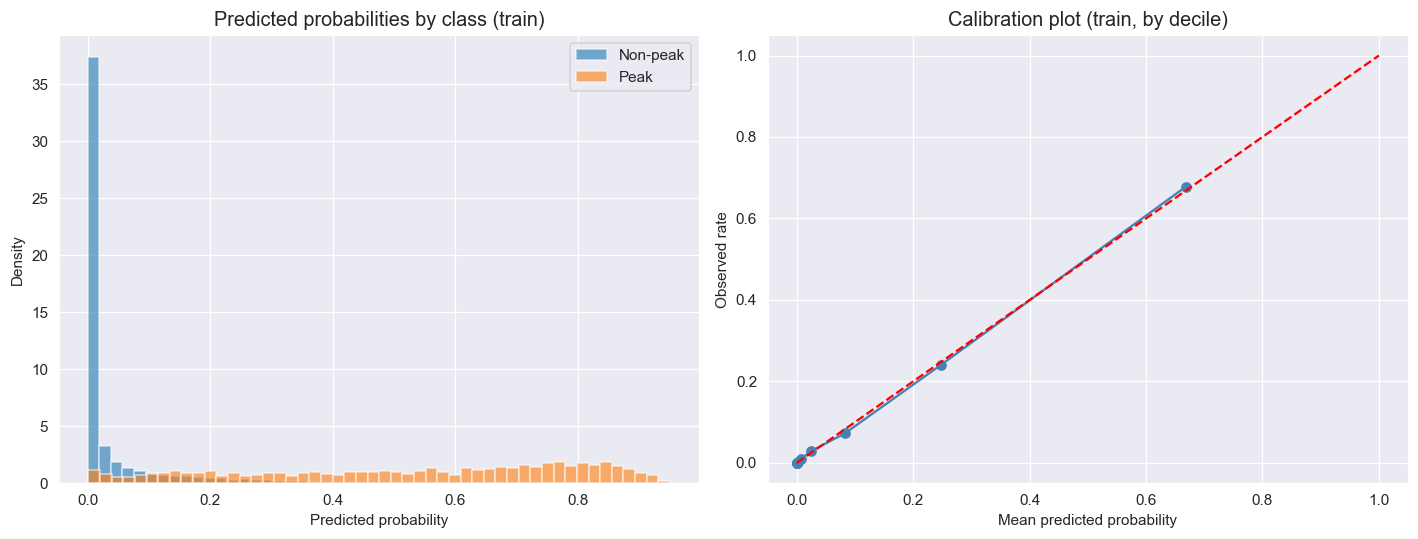

In [24]:
train_prob = model.predict(train_clean)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# predicted probability distribution by class
for label, val in [(0, 'Non-peak'), (1, 'Peak')]:
    mask = train_clean['is_peak'] == label
    axes[0].hist(train_prob[mask], bins=50, alpha=0.6,
                 label=val, density=True)
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Density')
axes[0].set_title('Predicted probabilities by class (train)')
axes[0].legend()

# calibration: mean predicted prob vs observed rate by decile
tmp = pd.DataFrame({'prob': train_prob, 'actual': train_clean['is_peak'].values})
tmp['decile'] = pd.qcut(tmp['prob'], 10, labels=False)
cal = tmp.groupby('decile').agg(mean_pred=('prob', 'mean'),
                                 obs_rate=('actual', 'mean'))
axes[1].plot(cal['mean_pred'], cal['obs_rate'], 'o-', color='steelblue')
axes[1].plot([0, 1], [0, 1], 'r--', lw=1.5)
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Observed rate')
axes[1].set_title('Calibration plot (train, by decile)')

plt.tight_layout()
plt.savefig('../outputs/figures/04_binomial/04_11_binomial_diagnostics.png', bbox_inches='tight')
plt.show()

#### 4. Coefficients
The is_weekend variable shows quasi-complete separation, weekend hours are almost never peak hours in the Zurich dataset, causing the MLE coefficient to diverge (-28.47, std_err = 14,699). This does not affect predictive performance (AUC = 0.959) but makes coefficient inference for this variable unreliable. This is a known limitation of logistic regression on structured energy data where calendar effects create near-perfect class separation.

In [30]:
coef = pd.DataFrame({
    'estimate':   model.params,
    'std_err':    model.bse,
    'p_value':    model.pvalues,
    'odds_ratio': np.exp(model.params)
}).round(4).sort_values('p_value')

print(coef)

                     estimate     std_err  p_value  odds_ratio
C(season)[T.summer]    3.1360      0.1924   0.0000     23.0126
C(season)[T.winter]   -0.7343      0.1400   0.0000      0.4798
T                     -0.1767      0.0106   0.0000      0.8380
StrGlo                -0.0009      0.0002   0.0000      0.9991
RainDur                0.0128      0.0019   0.0000      1.0129
hour_sin              -1.1957      0.0496   0.0000      0.3025
hour_cos              -2.9958      0.0988   0.0000      0.0500
month_sin              1.0560      0.1078   0.0000      2.8749
month_cos              1.9890      0.1300   0.0000      7.3081
T:hour_cos            -0.0791      0.0115   0.0000      0.9240
Intercept             -9.5056      3.3203   0.0042      0.0001
p                      0.0071      0.0034   0.0369      1.0072
Hr                     0.0047      0.0031   0.1242      1.0048
C(season)[T.spring]   -0.2070      0.1853   0.2638      0.8130
WVv                    0.0179      0.0249   0.4723     

exp(coef) gives odds ratios: above 1 increases peak odds, below 1 decreases.
Cyclic features dominate again. StrGlo < 1: sunny hours are not peak hours.
is_weekend < 1: fewer peak hours on weekends.

#### 5. Test Set Predictions

In [26]:
y_prob = model.predict(test_clean)
y_pred = (y_prob >= 0.3).astype(int)
y_true = test_clean['is_peak'].values

print(classification_report(y_true, y_pred, target_names=['Non-peak', 'Peak']))

              precision    recall  f1-score   support

    Non-peak       0.98      0.93      0.96      7961
        Peak       0.54      0.82      0.65       787

    accuracy                           0.92      8748
   macro avg       0.76      0.88      0.80      8748
weighted avg       0.94      0.92      0.93      8748



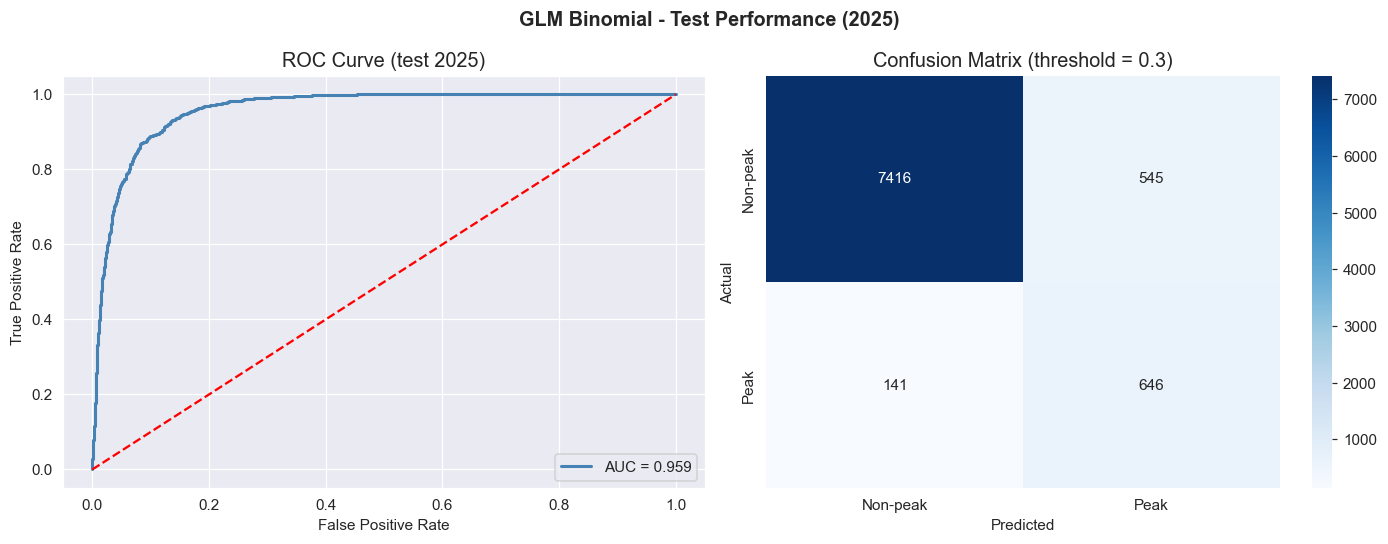

In [27]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'r--', lw=1.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (test 2025)')
axes[0].legend()

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Non-peak', 'Peak'],
            yticklabels=['Non-peak', 'Peak'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (threshold = 0.3)')

fig.suptitle('GLM Binomial - Test Performance (2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/04_binomial/04_12_binomial_roc_cm.png', bbox_inches='tight')
plt.show()

#### 6. Save Metrics

In [28]:
new_row = pd.DataFrame([{
    'model':    'GLM_Binomial',
    'rmse':     np.nan,
    'mae':      np.nan,
    'r2_train': round(pseudo_r2, 4),
    'r2_test': np.nan,
    'auc':      round(auc, 4)
}])

out = '../outputs/model_comparison.csv'
if os.path.exists(out):
    existing = pd.read_csv(out)
    existing = existing[existing['model'] != 'GLM_Binomial']
    new_row = pd.concat([existing, new_row], ignore_index=True)

new_row.to_csv(out, index=False)
print(new_row.to_string())

          model      rmse       mae  r2_train     auc  r2_test
0   NN (128,64)  2660.600  2038.200    0.9710     NaN      NaN
1           SVM   881.000   653.700    0.9967     NaN      NaN
2           GAM  3794.400  2520.100    0.9391     NaN   0.9411
3            LM  7623.700  6125.800    0.7855     NaN   0.7517
4   GLM_Poisson     2.611     1.427    0.7259     NaN      NaN
5  GLM_Binomial       NaN       NaN    0.5254  0.9593      NaN
